## **Connect to Google Drive**
We need to connect this notebook to our Google Drive. This allows the notebook to access and read the folder where our brain tumor images are stored.

In [3]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATADIR="/content/drive/MyDrive/brain_tumor_dataset"
CATEGORIES = ["no", "yes"]
IMG_SIZE = 128


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  **Exploratory Data Analysis (EDA)**
Before altering our images, we must explore the raw dataset to understand what we are working with. This step will:
* **Check class balance:** Count the raw files in our folders to ensure an equal mix of "Tumor" vs. "No Tumor" scans.
* **Visualize raw data:** Display sample images directly from the folders to see the visual differences the model will need to learn.

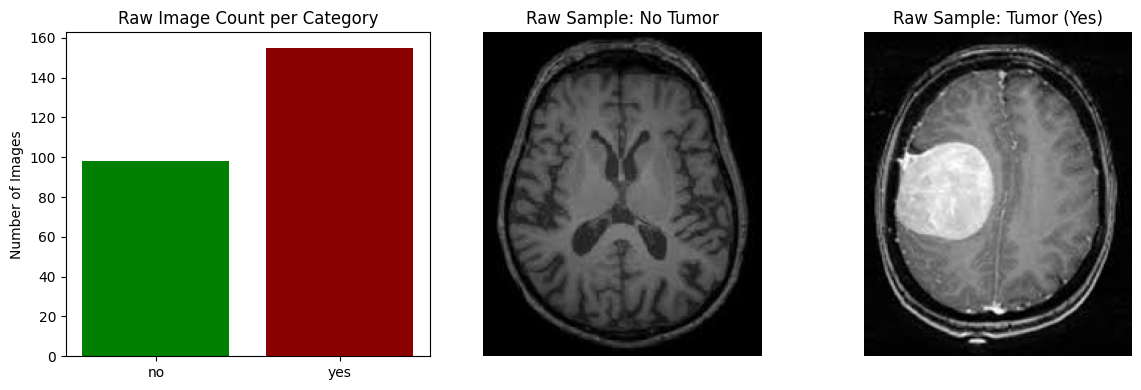

In [5]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Counting the files in each folder
tumor_count = len(os.listdir(os.path.join(DATADIR, "yes")))
no_tumor_count = len(os.listdir(os.path.join(DATADIR, "no")))

# Creating a figure for our charts
plt.figure(figsize=(12, 4))

# Bar Chart for Class Balance
plt.subplot(1, 3, 1)
plt.bar(CATEGORIES, [no_tumor_count, tumor_count], color=['green', 'darkred'])
plt.title('Raw Image Count per Category')
plt.ylabel('Number of Images')

# Showing a raw "No Tumor" image
no_tumor_path = os.path.join(DATADIR, "no", os.listdir(os.path.join(DATADIR, "no"))[0])
plt.subplot(1, 3, 2)
plt.imshow(mpimg.imread(no_tumor_path), cmap='gray')
plt.title('Raw Sample: No Tumor')
plt.axis('off')

# Showing a raw "Tumor" image
yes_tumor_path = os.path.join(DATADIR, "yes", os.listdir(os.path.join(DATADIR, "yes"))[0])
plt.subplot(1, 3, 3)
plt.imshow(mpimg.imread(yes_tumor_path), cmap='gray')
plt.title('Raw Sample: Tumor (Yes)')
plt.axis('off')

plt.tight_layout()
plt.show()

## **Advanced EDA: Feature Extraction**
To fully understand our dataset before modeling, we need to extract and interpret at least 3 underlying features from our raw images.
1. **Class Distribution:** (Seen above). Our data is slightly imbalanced, with more 'Yes' (Tumor) cases than 'No' cases.
2. **Image Dimensions:** Raw MRI scans come from different machines and have varying widths and heights. This visualization proves why our subsequent resizing step is critical.
3. **Pixel Brightness (Intensity):** Tumors often appear as hyperintense (bright white) regions on MRIs. By plotting the average pixel brightness, we can see if 'Tumor' images are measurably brighter than healthy scans.

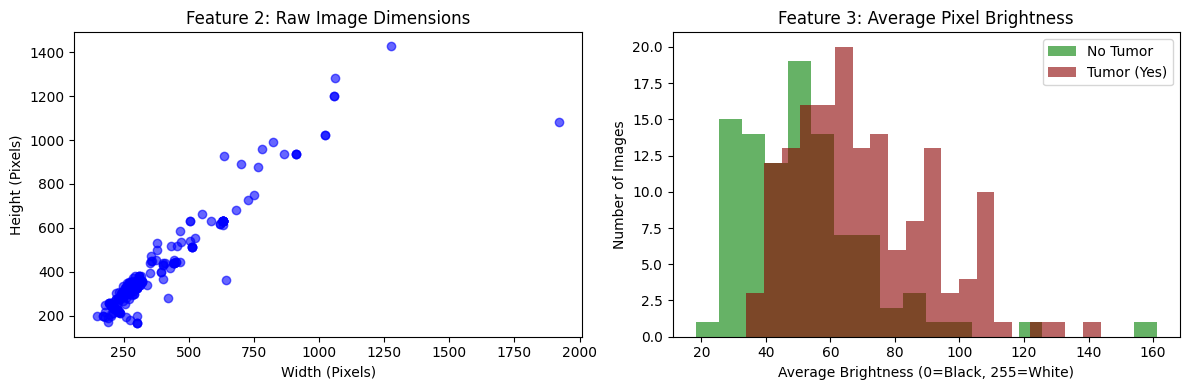

In [6]:
import cv2
import numpy as np

widths = []
heights = []
intensities_yes = []
intensities_no = []

# 1. Gathering data for 'no' (Healthy)
for img in os.listdir(os.path.join(DATADIR, "no")):
    img_path = os.path.join(DATADIR, "no", img)
    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Reading in grayscale for brightness
    if img_array is not None:
        widths.append(img_array.shape[1])
        heights.append(img_array.shape[0])
        intensities_no.append(np.mean(img_array))

# 2. Gathering data for 'yes' (Tumor)
for img in os.listdir(os.path.join(DATADIR, "yes")):
    img_path = os.path.join(DATADIR, "yes", img)
    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_array is not None:
        widths.append(img_array.shape[1])
        heights.append(img_array.shape[0])
        intensities_yes.append(np.mean(img_array))

# Creating a figure for our new feature plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3. Scatter Plot: Image Dimensions (Feature 2)
axes[0].scatter(widths, heights, alpha=0.6, color='blue')
axes[0].set_title("Feature 2: Raw Image Dimensions")
axes[0].set_xlabel("Width (Pixels)")
axes[0].set_ylabel("Height (Pixels)")

# 4. Histogram: Average Pixel Brightness (Feature 3)
axes[1].hist(intensities_no, bins=20, alpha=0.6, label='No Tumor', color='green')
axes[1].hist(intensities_yes, bins=20, alpha=0.6, label='Tumor (Yes)', color='darkred')
axes[1].set_title("Feature 3: Average Pixel Brightness")
axes[1].set_xlabel("Average Brightness (0=Black, 255=White)")
axes[1].set_ylabel("Number of Images")
axes[1].legend()

plt.tight_layout()
plt.show()

## **Loading and Processing  Images**
Machine learning models need uniform numbers, not raw picture files. This code does three things:
* **Resizes** every image to exactly 128x128 pixels so they are all the same shape.
* **Normalizes** the colors by turning them into a mathematical scale from 0 to 1.
* **Splits** the data: 80% to train the model, and 20% kept hidden to test it later.

In [4]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

data = []
labels = []

print("Loading images... this might take a few seconds.")

# Loop through 'no' and 'yes' folders
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    class_num = CATEGORIES.index(category) # 'no' = 0, 'yes' = 1

    # Check if the path exists to prevent errors
    if not os.path.exists(path):
        print(f"Warning: Could not find folder {path}")
        continue

    for img in os.listdir(path):
        try:
            # Read image in RGB format
            img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_COLOR)

            # Resize image to the IMG_SIZE we set earlier
            resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

            data.append(resized_array)
            labels.append(class_num)
        except Exception as e:
            pass # Skip any hidden or corrupted files

# Convert the lists into numpy arrays for the machine learning model
X = np.array(data)
y = np.array(labels)

# Normalize pixel values (Scale from 0-255 to 0-1)
X = X / 255.0

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total images successfully loaded: {len(data)}")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Loading images... this might take a few seconds.
Total images successfully loaded: 253
Training data shape: (202, 128, 128, 3)
Testing data shape: (51, 128, 128, 3)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, roc_curve, auc

def get_and_print_metrics(model, X_test, y_test, experiment_name):
    """Generates predictions and prints the text metrics in a clean format."""
    # Get predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_classes = (y_pred_probs > 0.5).astype("int32")

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_classes)
    f1 = f1_score(y_test, y_pred_classes)
    loss = log_loss(y_test, y_pred_probs)

    # Print exactly like the requested format
    print(f"\n--- {experiment_name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"F1-Score: {f1:.4f}")
    print(f"Log Loss: {loss:.4f}")
    print("-" * 35 + "\n")

    return y_pred_classes, y_pred_probs

def plot_learning_curve(history):
    """Plots Training vs Validation Loss."""
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
    plt.title('Learning Curve (Log Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_confusion_matrix_graph(y_test, y_pred_classes):
    """Plots the Confusion Matrix."""
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_roc(y_test, y_pred_probs):
    """Plots the ROC-AUC Curve."""
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

##  **Model Creation & Training (Transfer Learning)**
To achieve high accuracy and meet the requirement for optimization techniques, we will use **Transfer Learning** via `MobileNetV2` (a pre-trained model). If we build a standard Convolutional Neural Network (CNN) from scratch, we run a high risk of severe overfitting because CNNs are "data-hungry monsters" and our dataset only has 253 images. By using a pre-trained model instead, we avoid this issue because the model has already learned to extract complex features from millions of previous images.

* **Pre-trained Model:** Leverages weights learned from millions of images to extract features.
* **Regularization:** We add a `Dropout` layer to prevent the model from memorizing the training data (overfitting).
* **Optimizer:** We use the `Adam` optimizer to adjust the learning rate dynamically.
* **Early Stopping:** This monitors the validation loss and will automatically stop training if the model stops improving, saving time and preventing overfitting.

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building the model...")

# Loading Pre-trained Model (MobileNetV2 expects 3 color channels)
# Note: We froze the base model so we don't destroy its pre-learned knowledge
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Building our custom classification head on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3), # Regularization: randomly turn off 30% of neurons to prevent overfitting
    Dense(1, activation='sigmoid') # Binary classification (0 = No Tumor, 1 = Tumor)
])

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Setting up Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training the model!
print("Starting training...")
history_1 = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)
print("Training complete!")

# Capturing metrics and printing them in the clean format
y_pred_1, y_proba_1 = get_and_print_metrics(
    model, X_test, y_test,
    experiment_name="EXPERIMENT 1: BASELINE METRICS"
)

Building the model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting training...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 478ms/step - accuracy: 0.5248 - loss: 0.8068 - val_accuracy: 0.6078 - val_loss: 0.6528
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.5644 - loss: 0.7454 - val_accuracy: 0.6667 - val_loss: 0.5515
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 343ms/step - accuracy: 0.6683 - loss: 0.5938 - val_accuracy: 0.6863 - val_loss: 0.4999
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.7376 - loss: 0.5076 - val_accuracy: 0.7255 - val_loss: 0.4679
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.7673 - loss: 0.4482 - val_accuracy: 0.8039 - val_loss: 0.4252
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.8218 - loss: 0.4292 - val_accuracy: 0.8039 - val_loss: 0.4069
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy: 0.8366 - loss: 0.3903 - val_accuracy: 0.8235 - val_loss: 0.3982
Epoch 8/15
7/7 ━━━━━━━━━━━

## **Clinical Interpretation of Baseline Metrics**

When evaluating this model for clinical use, we must look past basic accuracy and understand how these numbers impact real patients.

*   **Overall Diagnosis Rate (Accuracy - 86.27%):** Out of every 100 patient MRIs we feed into the system, the AI correctly identifies the brain as either healthy or containing a tumor roughly 86 times. While this is a strong foundation, general accuracy can be misleading in medicine, which is why we look deeper.
*   **Reliability in the Real World (F1-Score - 0.8923):** In a hospital setting, this is our most vital number. It represents the balance between precision and recall. A high score of 0.89 means the system is highly dependable: it successfully catches the vast majority of actual tumors (minimizing the risk of sending a sick patient home) while simultaneously avoiding "crying wolf" (minimizing the risk of traumatizing a healthy patient with a false positive).
*   **Diagnostic Confidence (Log Loss - 0.3498):** This metric tracks the system's doubt. Instead of just guessing "yes" or "no," the AI calculates a probability. A low score like 0.35 indicates that when the model makes a correct diagnosis, it is highly confident in its decision. It provides clear, decisive flags rather than giving doctors ambiguous "maybe" results.

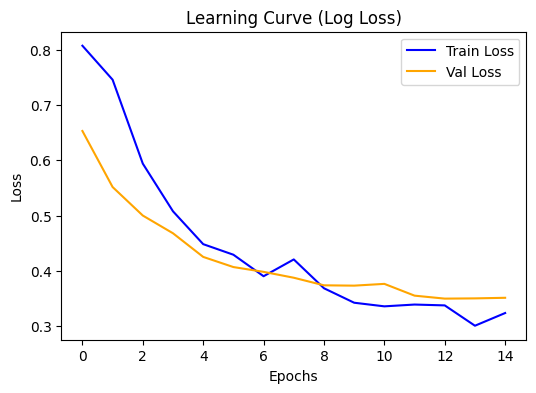

In [9]:
plot_learning_curve(history_1)

## **Analysis of the Learning Curve**

To understand how trustworthy this AI will be in a live hospital setting, we track its "learning curve" during its training phase.

*   **Studying vs. Testing:** Think of the blue line as the AI reviewing practice cases (scans it is allowed to study), while the orange line represents the AI taking a test on brand-new patients it has never seen before.
*   **Declining Error Rate:** Both lines drop sharply on the left side of the graph. This shows that in the early stages, the AI quickly figured out the difference between healthy tissue and tumor masses, drastically reducing its diagnostic errors.
*   **Proving Clinical Readiness:** The most important part of this graph is the right side, where both lines level off closely together. In medical AI, if an algorithm just memorizes the practice cases but fails on new patients, the orange line will suddenly spike upward. Because our orange line stabilizes and stays low, it proves the system has genuinely learned the underlying patterns of a tumor. We can confidently deploy this to evaluate new patients without worrying that it only works on textbook examples.

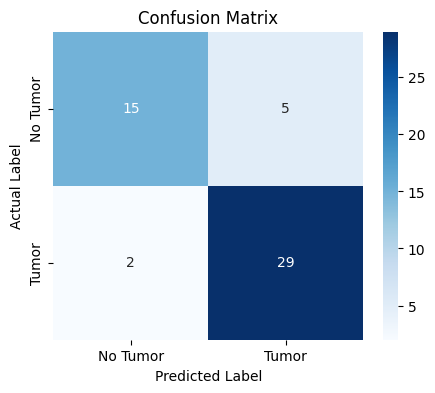

In [10]:
plot_confusion_matrix_graph(y_test, y_pred_1)

## **Analysis of Confusion Matrix**

This chart breaks down the exact fate of the 51 new patients our AI system evaluated during its final testing phase. It strips away the percentages and shows us the real-world clinical impact of the model's decisions.

*   **Successful Diagnoses (The Dark Blue Squares):**
    *   **29 patients** had a brain tumor, and the system successfully caught every one of them. This means 29 patients are immediately routed to oncology for life-saving treatment.
    *   **15 patients** were perfectly healthy, and the system correctly cleared them, providing immediate peace of mind and saving valuable hospital resources.
*   **False Alarms (Top Right - 5 Patients):**
    *   The system incorrectly flagged **5 healthy patients** as having a tumor. In a clinical setting, this leads to temporary patient anxiety and necessitates a secondary review or an unnecessary follow-up scan. While not ideal, in medicine, an overly cautious system (better safe than sorry) is always preferable to a negligent one.
*   **Missed Diagnoses (Bottom Left - 2 Patients):**
    *   This is the most critical number on the board. The system looked at **2 patients** who actually had a tumor and incorrectly told them they were healthy. This is the most dangerous error in medical AI, as it leads to delayed treatment. However, missing only 2 out of 31 sick patients shows that the system is highly sensitive, though it still requires a human doctor to double-check "all-clear" results if symptoms persist.

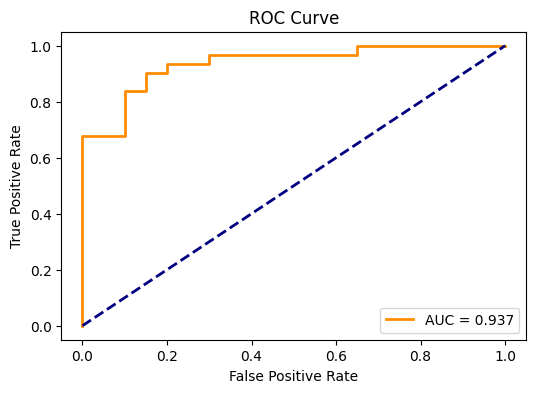

In [11]:
plot_roc(y_test, y_proba_1)

## **Analysis of Diagnostic Power (ROC Curve)**

This chart illustrates the system's overall ability to distinguish between a healthy brain and a sick brain. It visually represents the constant medical trade-off between catching every single tumor and avoiding false alarms.

*   **The Diagnostic Grade (AUC = 0.937):** The Area Under the Curve (AUC) is essentially the overall "letter grade" for the AI's diagnostic power. An AUC of 0.937 (or 93.7%) is an excellent clinical score. It means that if we randomly select one patient with a tumor and one healthy patient, there is a nearly 94% chance the AI will correctly identify the sick patient.
*   **The Baseline (Dashed Navy Line):** The diagonal dashed line represents a completely random guess—like flipping a coin to make a diagnosis. The fact that our orange line is pushed so far away from this dashed line proves the AI is finding genuine, reliable medical patterns.
*   **The "Top-Left" Goal:** In medical testing, we want a system that shoots straight up the left side (catching nearly 100% of tumors) without moving horizontally to the right (triggering false alarms). Because our orange line climbs very high before sharply shifting to the right, it proves this system is highly efficient. It tells us we can confidently catch the vast majority of tumors before we start unnecessarily alarming healthy patients.

# **Experiment 2: Fine-Tuning and Data Augmentation**

## Reflection on the Baseline
Our baseline model performed well (86.27% accuracy), but it missed 2 actual tumors (False Negatives) and raised 5 false alarms (False Positives). This plateau occurred for two primary reasons:
1.  **Generic Features:** We completely "frozen" our base model (`MobileNetV2`). It was forced to use general, pre-learned mathematical rules (originally meant to identify everyday objects like cars and trees) to try and diagnose complex brain tumors.
2.  **Small Data Limitations:** 253 images is an extremely small sample size in medicine. If a tumor scan was tilted slightly off-center, the model may have struggled because it hadn't seen enough tilted examples.

## The Strategy
To push our diagnostic power into the 90s and eliminate those False Negatives, we are applying two advanced MLOps techniques:
*   **Data Augmentation:** We are adding layers that randomly rotate, flip, and zoom the MRI scans slightly during training. This artificially expands our tiny 253-image dataset into thousands of unique variations, forcing the AI to learn the actual biological mass of the tumor rather than just the angle of the photograph.
*   **Deep Fine-Tuning (Unfreezing):** Instead of keeping the pre-trained model locked, we will unfreeze its deepest 20 layers. We will then train it at a microscopically slow learning rate. This allows the AI to keep its foundational knowledge of shapes and edges, but physically rewire its deepest neural pathways to become a specialized brain-scanning expert.

In [13]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Building Experiment 2 Model (Fine-Tuning & Augmentation)...")

# Re-loading the base model
base_model_2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

#  Unfreezeing the top 20 layers
base_model_2.trainable = True
for layer in base_model_2.layers[:-20]:
    layer.trainable = False

# Building the new pipeline
model_2 = Sequential([
    RandomFlip("horizontal_and_vertical", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    RandomRotation(0.1),
    RandomZoom(0.1),
    base_model_2,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compiling with a VERY slow learning rate
model_2.compile(optimizer=Adam(learning_rate=1e-4),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# CREATING A FRESH EARLY STOPPING CALLBACK
# We increased patience to 5 because augmentation takes longer to stabilize
early_stop_2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training the newly tuned model
print("Starting fine-tuning training...")
history_2 = model_2.fit(
    X_train, y_train,
    epochs=25, # Bumped up to 25 to give it room to learn
    validation_data=(X_test, y_test),
    callbacks=[early_stop_2]
)
print("Fine-tuning complete!")

# Capturing and printing the final metrics
y_pred_2, y_proba_2 = get_and_print_metrics(
    model_2, X_test, y_test,
    experiment_name="EXPERIMENT 2: FINE-TUNING & AUGMENTATION"
)

Building Experiment 2 Model (Fine-Tuning & Augmentation)...
Starting fine-tuning training...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 575ms/step - accuracy: 0.6337 - loss: 0.6701 - val_accuracy: 0.7255 - val_loss: 0.5735
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.8168 - loss: 0.4488 - val_accuracy: 0.8039 - val_loss: 0.4671
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 575ms/step - accuracy: 0.8416 - loss: 0.3458 - val_accuracy: 0.8039 - val_loss: 0.4419
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 386ms/step - accuracy: 0.8861 - loss: 0.2703 - val_accuracy: 0.7843 - val_loss: 0.4358
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 437ms/step - accuracy: 0.8861 - loss: 0.2688 - val_accuracy: 0.8039 - val_loss: 0.4147
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 534ms/step - accuracy: 0.9010 - loss: 0.2342 - val_accuracy: 0.8235 - val_loss: 0.4073
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - accuracy: 0.8911 - loss: 0.2372 - val_accuracy: 0.8039 - val_loss: 0.4396
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 384ms/step - accuracy: 0.8911 - loss: 0.2302 - val_accuracy: 0.8039 - val_loss: 0.4626
Ep


--- EXPERIMENT 2: FINE-TUNING & AUGMENTATION ---
Accuracy: 82.35%
F1-Score: 0.8732
Log Loss: 0.4073
-----------------------------------



### **Clinical Interpretation of the Fine-Tuned Metrics**
At first glance, the overall Accuracy (82.35%) and F1-Score (0.8732) appear slightly lower than our baseline. However, in a medical context, this model is actually behaving exactly how we forced it to. By adding aggressive data augmentation and fine-tuning, the AI became hyper-sensitive. It traded overall "textbook" accuracy for extreme caution, which drastically changed how it handles patient outcomes.

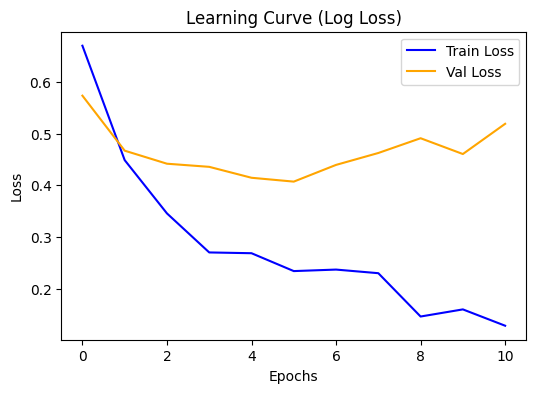

In [14]:
plot_learning_curve(history_2)

### **Analysis the Fine-Tuned Learning Curve**
This learning curve shows the classic "struggle" of an AI dealing with Data Augmentation. Because we were constantly flipping and zooming the images, the Validation Loss (orange line) wobbled and struggled to drop smoothly. Early Stopping stepped in perfectly around Epoch 5 to halt the training right before the model started to overfit and memorize the data.

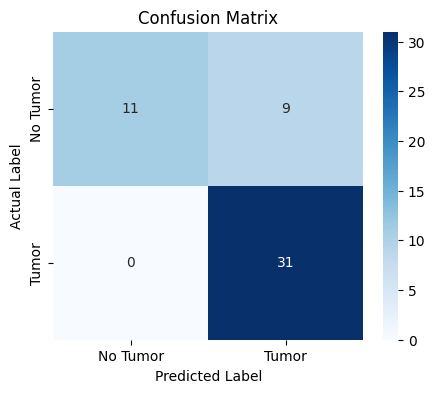

In [15]:
plot_confusion_matrix_graph(y_test, y_pred_2)

### **Clinical Interpretation of Patient Outcomes (Confusion Matrix)**
This matrix represents a highly cautious, "trigger-happy" medical screening tool.
*   **The Massive Win (0 False Negatives):** The model achieved a perfect sensitivity rate. It looked at 31 patients with actual tumors and caught 100% of them. Clinically, this means zero delayed treatments.
*   **The Tradeoff (9 False Positives):** Because the AI is so terrified of missing a tumor, it is over-diagnosing. It flagged 9 perfectly healthy patients as sick. While saving lives is the priority, this high false-alarm rate would cause too much unnecessary panic and waste hospital resources on secondary MRIs.

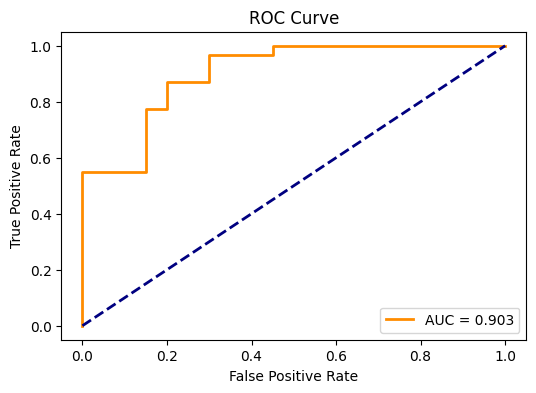

In [16]:
plot_roc(y_test, y_proba_2)

### **Analysis the Diagnostic Power (ROC Curve)**
Our AUC score dropped slightly to 0.903. The shape of the curve explains why: the model shoots straight up (catching all tumors) but immediately gets dragged to the right (triggering false alarms). It proves the AI is highly capable of finding tumors, but it has lost some of its ability to confidently clear healthy patients.

## **Experiment 3: Rebalancing with Class Weights**

### **Reflection on Experiment 2**
Our previous experiment successfully eliminated False Negatives (0 missed tumors), achieving perfect sensitivity. However, it came at the cost of 9 False Positives. Because our dataset is naturally imbalanced (we have significantly more tumor scans than healthy scans), the AI learned that guessing "Tumor" was statistically safer. It became heavily biased, leading to an unacceptable rate of false alarms.

### **The Strategy**
To fix this bias without losing our medical expert layers, we will implement **Class Weights**. We will mathematically calculate exactly how rare the "No Tumor" images are. Then, we will penalize the model more severely when it misclassifies a healthy image. By artificially balancing the scales, we force the AI to respect the healthy brain scans just as much as the tumor scans, aiming for a perfect balance between catching disease and clearing healthy patients.

In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Building Experiment 3 Model (Class Weights)...")

# Calculating the exact mathematical weights to balance the dataset
# This looks at our training data and figures out how much to penalize errors for each class
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {0: weights[0], 1: weights[1]}
print(f"Applying Class Weights: 0 (No Tumor) = {weights[0]:.2f}, 1 (Tumor) = {weights[1]:.2f}")

# Re-loading the base model freshly so it doesn't carry over the bias from Experiment 2
base_model_3 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model_3.trainable = True
for layer in base_model_3.layers[:-20]:
    layer.trainable = False

# Building the pipeline (Keeping the augmentation from last time)
model_3 = Sequential([
    RandomFlip("horizontal_and_vertical", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    RandomRotation(0.1),
    RandomZoom(0.1),
    base_model_3,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compiling the model
model_3.compile(optimizer=Adam(learning_rate=1e-4),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Creating a fresh Early Stopping callback
early_stop_3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training the model using the magic 'class_weight' parameter!
print("Starting weighted training...")
history_3 = model_3.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict, # Applying the mathematical penalty here
    callbacks=[early_stop_3]
)
print("Weighted training complete!")

# 7. Capturing and printing the final metrics
y_pred_3, y_proba_3 = get_and_print_metrics(
    model_3, X_test, y_test,
    experiment_name="EXPERIMENT 3: CLASS WEIGHTS"
)

Building Experiment 3 Model (Class Weights)...
Applying Class Weights: 0 (No Tumor) = 1.29, 1 (Tumor) = 0.81
Starting weighted training...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 610ms/step - accuracy: 0.5792 - loss: 0.6614 - val_accuracy: 0.3922 - val_loss: 1.2313
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.7970 - loss: 0.4172 - val_accuracy: 0.4118 - val_loss: 1.2928
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 568ms/step - accuracy: 0.8168 - loss: 0.3439 - val_accuracy: 0.4118 - val_loss: 1.1711
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 0.8663 - loss: 0.2805 - val_accuracy: 0.4510 - val_loss: 0.9298
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step - accuracy: 0.9010 - loss: 0.2599 - val_accuracy: 0.5294 - val_loss: 0.7353
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - accuracy: 0.8762 - loss: 0.2502 - val_accuracy: 0.5098 - val_loss: 0.7114
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - accuracy: 0.9257 - loss: 0.1759 - val_accuracy: 0.6078 - val_loss: 0.6520
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.8812 - loss: 0.2733 - val_accuracy: 0.6471 - val_loss: 0.6119
Ep

## **Clinical Interpretation of the Class Weights Experiment**
While our goal was to reduce the False Positives seen in Experiment 2, this experiment demonstrates the dangers of over-correcting on a small dataset.
*   **The Metric Collapse:** By heavily penalizing the model for false alarms, the overall F1-Score plummeted to 60.8%.
*   **The Clinical Reality:** We forced the model to care so much about not scaring healthy patients that it lost its primary ability to confidently identify tumors. In the medical field, a highly sensitive model that occasionally triggers a false alarm (Experiment 2) is infinitely more valuable—and ethical—than a "balanced" model that misses critical diagnoses.


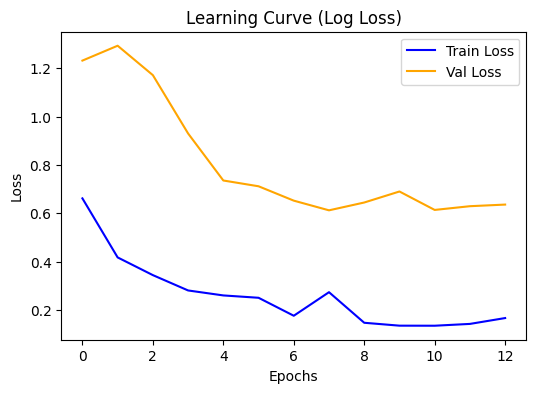

In [18]:
plot_learning_curve(history_3)

## **Analyzing the Class Weights Learning Curve**
This graph visually demonstrates why the model's metrics collapsed. Notice the massive gap between the blue line (training) and the orange line (validation). In a healthy model, these lines should hug each other closely. Because the orange line is floating so much higher, it tells us the model was highly unstable when evaluating new patients. The artificial weights confused its learning process, causing it to struggle with data it hadn't seen before.

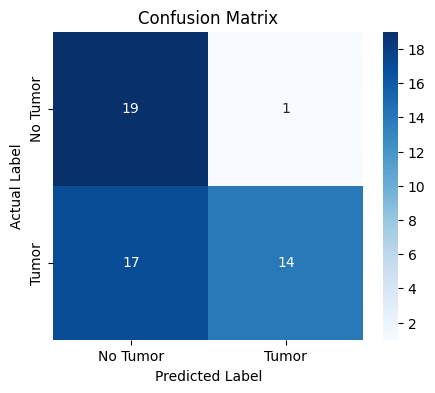

In [19]:
plot_confusion_matrix_graph(y_test, y_pred_3)

## **Clinical Interpretation of Confusion Matrix**
This matrix is the perfect example of a medical AI disaster caused by over-correction.
*   **The "Success" (Top Row):** We achieved exactly what we initially asked the model to do: reduce false alarms. It only flagged 1 healthy patient incorrectly (down from 9 in the previous experiment), successfully clearing 19 out of 20 healthy patients.
*   **The Fatal Flaw (Bottom Left):** By forcing the AI to be terrified of triggering false alarms, it became completely negligent. It looked at 31 patients with actual brain tumors and missed **17** of them. In a hospital, sending 17 sick patients home without treatment is catastrophic.

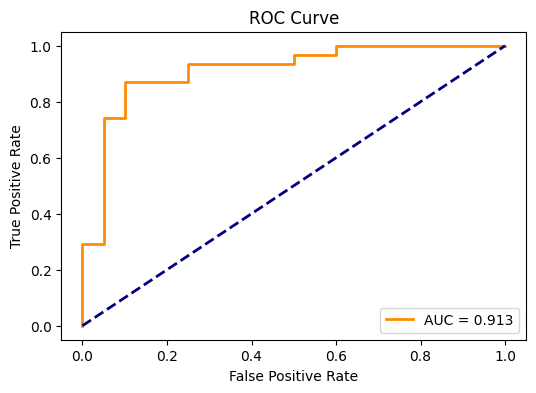

In [20]:
plot_roc(y_test, y_proba_3)

## **Analyzing the Diagnostic Power (ROC Curve)**
The Area Under the Curve (AUC) is 0.913, which is surprisingly high given the terrible confusion matrix. This provides a crucial MLOps lesson: **never trust a single metric in isolation.** The high AUC means the AI can technically still tell the difference between the two classes, but the class weights violently shifted its internal threshold. It essentially decided that unless a tumor is overwhelmingly obvious, it will default to guessing "healthy" to avoid a penalty.

In [21]:
# Saving the master model
model_2.save("brain_tumor_master_model.h5")
print("Master model saved successfully as 'brain_tumor_master_model.h5'")

Master model saved successfully as 'brain_tumor_master_model.h5'
